<a href="https://colab.research.google.com/github/bhagyawanthv/Bhgayawantha123/blob/main/Fraud_Detection_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [2]:
from google.colab import files
uploaded = files.upload()


Saving creditcard.csv to creditcard.csv


In [7]:
df = pd.read_csv("creditcard.csv")

In [8]:
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [9]:
df.shape

(284807, 31)

In [10]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [13]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [14]:
#Calculate fraud percentage:

fraud_percentage = (
    df["Class"].mean()*100
)
print(f"fraud transactions:{fraud_percentage:.2f}%")

fraud transactions:0.17%


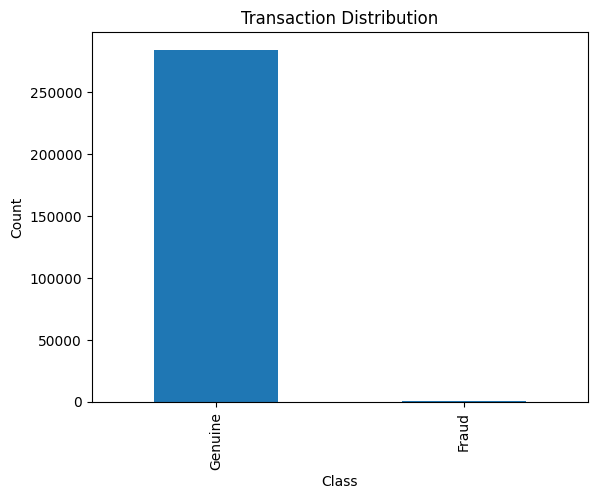

In [15]:
df["Class"].value_counts().plot(kind="bar")

plt.xticks([0,1], ["Genuine","Fraud"])
plt.ylabel("Count")
plt.title("Transaction Distribution")

plt.show()

In [16]:
scaler = StandardScaler()
df["scaled_amount"]=scaler.fit_transform(
    df[["Amount"]]
)

df = df.drop(["Time","Amount"],axis = 1)

In [17]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [20]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [22]:
print(confusion_matrix(y_test, y_pred))

[[56851    13]
 [   35    63]]


In [23]:
auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.9560


In [24]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)